# [실습1] 양극소재 결정구조 데이터 분석 및 전처리 (정답)
---

## 실습 목표

- Python 실행 환경와 실습 데이터를 확인합니다.
- 데이터를 간단하게 분석합니다.
- 결측 데이터, 이상 데이터 등에 대한 전처리를 수행합니다.
- 데이터를 학습/테스트/검증 데이터셋으로 구분합니다.

---

## 실습 목차

1. **환경 설정 및 데이터 로딩** 

2. **데이터 구성 요소 확인** 

3. **결측 데이터 식별**

4. **결측값 대체** 

5. **이상치 전처리** 

6. **실습 데이터 불러오기 및 전처리 알고리즘 적용**

7. **데이터 구분** 
---

## 실습 개요

이번 실습에서는 양극재 결정구조 분류 데이터셋의 구성 요소를 확인하고 간단한 분석을 해볼 예정입니다. 이를 위해 토이 데이터셋을 이용해 사전에 연습해본 후, 이를 그대로 실습 데이터에 적용해볼 예정입니다.

---

## 1. 환경 설정 및 데이터 로딩

---

### 1.1 필수 라이브러리 불러오기
데이터를 불러오고 분석하기 위해 사용해야하는 라이브러리들을 불러옵니다. 이번 실습이 아닌 추후 개인 컴퓨터에서 불러올 경우, 해당 라이브러리들의 설치가 필요합니다. 

In [1]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import scipy
import yellowbrick


각 라이브러리가 어떤 코드에서 사용되는지 정확히 파악하기 위해, 세부 함수들은 __그 함수를 사용할 때__ 불러올 것입니다.

---

### 1.2 토이 데이터 불러오기
양극재 결정구조 분류 데이터셋을 이용해 실습을 진행하기 전, 간단한 토이 데이터셋을 이용해 일반적인 데이터 전처리 과정이 어떻게 이뤄지는지 살펴볼 예정입니다.

토이 데이터셋은 인공지능을 입문할 때 가장 많이 사용하는 'titanic dataset'입니다. 

해당 데이터에는 타이타닉 사건 때 배에 있었던 승객들의 명단을 포함하고 있습니다.

pandas 라이브러리를 이용해 데이터를 불러옵니다.

In [2]:
df = pd.read_csv('./data/titanic.csv')  # df: dataframe의 줄임말
print(df)

     PassengerId  Survived  Pclass   
0              1         0       3  \
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp   
0                              Braund, Mr. Owen Harris    male  22.0      1  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [3]:
# shape 기능을 이용하면 데이터의 차원을 확인할 수 있습니다.
print(df.shape)

(891, 12)


In [4]:
# display 함수를 이용하면 표 형태로 데이터 확인이 가능합니다.
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


---

## 2. 데이터 구성 요소 확인
---
### 2.1 데이터 자료형 확인
데이터를 변수나 파일에 저장할 때, 크게 네 가지 형태 중 하나로 저장하게 됩니다:

1. __float__: 실수
2. __int__: 정수
3. __bool__: 참 혹은 거짓
4. __object__: 글자들 (현재는 string 타입을 object 타입으로 표시, 변환 가능)

이 네 가지 형태를 자료형(data type)이라고 하고, 프로그래밍 언어에서 흔히 __'dtype'__이라고 줄여서 씁니다.

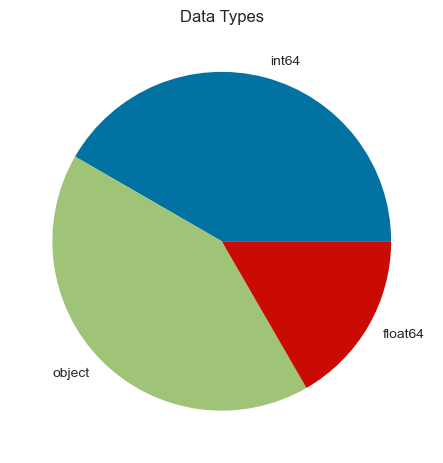

In [5]:
plt.figure()
df.dtypes.value_counts().plot.pie(ylabel='')
plt.title('Data Types')
plt.show()

이 중, object 자료형, 즉 글자들로 이뤄진 데이터는 인공지능 모델에 어떻게 활용할지 잘 고려해봐야 합니다.

글자 데이터 중, 모델의 예측 성능에 전혀 도움이 되지 않는 데이터도 있고, 도움이 되더라도 전처리를 거쳐야하는 경우가 많습니다.

### 2.2 데이터 통계량 확인
양극재 결정구조 분류 데이터셋에서 일반적인 통계량을 확인합니다. 흔히 확인하는 데이터 통계량은 다음과 같습니다:
- 평균(mean)
- 표준편차(std)
- 제 1 사분위수(25% quantile)
- 제 3 사분위수(75% quantile)
- 최소값(min)
- 최대값(max)

숫자 데이터인 int, float에 대해서만 통계량을 확인합니다.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


---

### 2.3 데이터 고유값 확인
데이터 항목 별 고유값의 갯수를 확인합니다. 고유값의 갯수에 따라 카테고리화(categorize)를 할지 미리 결정할 수 있습니다. 해당 내용은 아래에서 자세히 다룹니다.

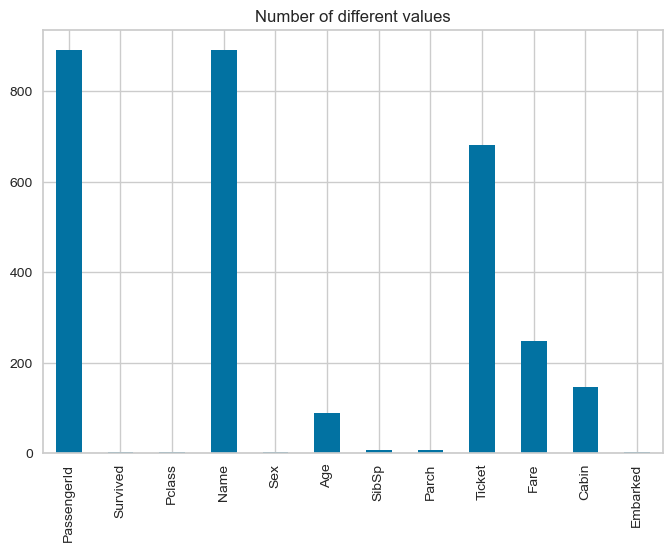

In [7]:
plt.figure()
df.nunique().plot.bar()
plt.title('Number of different values')
plt.show()

Passenger, Name, Ticket 데이터 항목은 전체 데이터 갯수에 비해 과하게 많은 고유값을 갖고 있다는 것을 확인할 수 있습니다.

데이터 항목 이름에서도 유추할 수 있듯이, 글자 데이터이기 때문에 생기는 대표적인 현상입니다.

---

## 3. 결측 데이터 식별
---
### 3.1 결측치 갯수 확인

결측치가 있는지 테스트합니다. 결측치는 missing data라고도 부릅니다.
#### 결측치란?
- 데이터베이스 구축 과정에서, 해당 항목에 속하지 않아서 데이터 자체를 비어두는 경우 등, 특정 이유 때문에 없는 데이터가 존재할 수 있습니다. 이러한 빈 데이터를 결측치(missing data)라고 합니다.
- 기본 Python 언어에서는 __None__ 이라고 표현하고, 특정 라이브러리에서는 __NaN__ 이라고 표현합니다. 
- 다른 언어에서는 __Null__ 등으로 표현되기도 합니다.

pandas 라이브러리의 isnull() 함수를 이용해 결측 데이터의 갯수를 확인할 수 있습니다.

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age, Cabin, Embarked 데이터에 결측 데이터가 존재하는 것을 확인할 수 있습니다.

결측 데이터가 전체 데이터 항목 중 차지하는 비율을 아래와 같이 확인할 수 있습니다.

In [9]:
isNaN = df.isna().sum().sort_values(ascending=True)
isNaN_ratio = isNaN/df.shape[0]
print("NaN 데이터 갯수: \n", isNaN)
print("\n")
print("NaN 데이터 비율: \n", isNaN_ratio)

NaN 데이터 갯수: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64


NaN 데이터 비율: 
 PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Embarked       0.002245
Age            0.198653
Cabin          0.771044
dtype: float64


Embarded는 결측치가 2개만 존재하고, Age는 대략 20%의 결측치가 존재합니다.

또, Cabin 항목은 77%가 결측치인 것을 확인할 수 있습니다.

---

### 3.2 결측 데이터 항목 식별

만약 결측치가 특정 비율보다 많다면, 해당 데이터 항목은 학습에 사용하기 어렵습니다. 이러한 데이터 항목을 식별하고 학습 데이터에서 제거해야 합니다.

만약 결측 데이터 항목이 있다면 아래와 같이 자동으로 식별할 수 있습니다.

In [10]:
def check_NaN(df, threshold_NaN):  
    isNaN_ratio = (df.isna().sum()/df.shape[0]).sort_values(ascending=True)
    drop_cols = []
    if isNaN_ratio.max() == 0.0:
        print("데이터프레임 안에 NaN 데이터가 없습니다.")
    else:
        drop_cols = np.array(isNaN_ratio[isNaN_ratio > threshold_NaN].index)
        print('NaN 데이터의 비율이', threshold_NaN*100,'% 를 넘는 데이터 형을 식별합니다. 데이터:', drop_cols)
    return drop_cols

threshold_NaN 변수는 사용자가 정의하는 임계값입니다. 결측치가 전체 데이터 중 30% 가 넘는다면 결측 데이터 항목으로 식별하겠습니다.

In [11]:
threshold_NaN = 0.3
drop_cols = check_NaN(df, threshold_NaN)

NaN 데이터의 비율이 30.0 % 를 넘는 데이터 형을 식별합니다. 데이터: ['Cabin']


---

### 3.3 결측 데이터 항목 제거
결측 데이터 항목으로 식별된 것들은 학습에 사용하기에는 너무 결측된 데이터가 많기 때문에, 해당 데이터를 사전에 제거합니다.

In [12]:
df = df.drop(drop_cols, axis=1)
print(df.shape)

(891, 11)


---

## 4. 결측값 대체
---
### 4.1 결측값 대체(Data Imputation)
너무 많은 결측치를 포함하는 결측 데이터 항목은 사전에 제거되었습니다. 남은 데이터 항목 중 데이터 결측치가 있을 경우, 빈 데이터 공간을 유의미한 데이터로 채워줘야 합니다.

데이터의 통계적인 특성을 고려하여 빈 데이터를 채우는 것을 결측값 대체(Data Imputation)이라고 합니다.

결측값 대체는 sklearn 라이브러리의 Iterative Imputer 함수를 이용해 수행합니다.

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
def imputation(df): 
    isna_stat = (df.isna().sum()/df.shape[0]).sort_values(ascending=True) 
    if isna_stat.max() > 0.0: 
       print('IterativeImputer를 이용해 데이터 결측값을 대체합니다.') 
       df = pd.DataFrame(IterativeImputer(random_state=0).fit_transform(df), columns = df.columns)  
    else: 
       print('결측값 대체를 할 필요가 없습니다.')
    return df

통계적 특성을 이용하므로, 숫자 데이터에 대해서만 결측값 대체를 수행할 수 있습니다. 

물론, 글자 데이터를 숫자 데이터로 카테고리화 해준 뒤에는 결측값 대체를 수행할 수 있습니다. 하지만 본 실습에서는 우선 숫자 데이터에 대해서만 결측값 대체를 수행해보겠습니다. 

토이 데이터셋 중 숫자 데이터 항목만 선택합니다.

In [14]:
df_imputed = df.select_dtypes(include='number')
display(df_imputed)
df_imputed.isnull().sum()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

숫자 데이터인 Age 데이터 항목에 177 개의 결측치가 있습니다. 사전에 정의한 imputation() 함수를 이용해 결측치 대체를 수행합니다.

In [15]:
df_imputed = imputation(df_imputed)
display(df_imputed)
df_imputed.isnull().sum()

IterativeImputer를 이용해 데이터 결측값을 대체합니다.


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.000000,1.0,0.0,7.2500
1,2.0,1.0,1.0,38.000000,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.000000,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.000000,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.000000,0.0,0.0,8.0500
...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,27.000000,0.0,0.0,13.0000
887,888.0,1.0,1.0,19.000000,0.0,0.0,30.0000
888,889.0,0.0,3.0,23.414502,1.0,2.0,23.4500
889,890.0,1.0,1.0,26.000000,0.0,0.0,30.0000


PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

Age 데이터 항목의 모든 결측값을 성공적으로 대체하였습니다.

---

## 5. 이상치 전처리
---
### 5.1 이상치 검출 및 제거
현실 세계에는 많은 불확실성이 존재합니다. 특히, 데이터를 센서를 통해 획득할 때는 센서의 한계 때문에 이상치(outlier)가 기록되기도 합니다. 

이러한 데이터는 학습 성능을 크게 저하시키기 때문에, 이상치라는 것이 확실하다면 이를 사전이 제거해주는 전처리 과정을 거쳐야합니다.

데이터 이상치를 판별할 때 Z score를 고려하는 경우가 많습니다.

threshold_Z 변수는 사용자가 정의하는 임계값입니다. Z score가 3.0 이상일 경우, 이상치라고 판단하겠습니다.

In [16]:
from scipy import stats
threshold_Z = 3.0
def get_outliers(df, threshold_Z):
   Z_score = np.abs(stats.zscore(df)) 
   non_outliers =  (Z_score < threshold_Z).all(axis=1)
   outlier_index = non_outliers[non_outliers == False].index

   if len(outlier_index) != 0:
      print("이상치를 총 {}개 검출했습니다. 이상치를 갖는 데이터 행은 아래와 같습니다:".format(len(outlier_index)))
      print(outlier_index)
   else:
      print('현재 threshold_Z을 기반으로 검사했을 때 이상치를 찾지 못했습니다.') 
   return non_outliers

사전에 정의한 outliters() 함수를 이용해 이상치를 검출합니다.

In [17]:
df = df_imputed
non_outliers = get_outliers(df, threshold_Z)

이상치를 총 69개 검출했습니다. 이상치를 갖는 데이터 행은 아래와 같습니다:
Index([ 13,  16,  25,  27,  50,  59,  68,  71,  86,  88,  96, 116, 118, 119,
       159, 164, 167, 171, 180, 182, 201, 233, 258, 261, 266, 278, 299, 311,
       324, 341, 360, 377, 380, 386, 437, 438, 480, 493, 527, 541, 542, 557,
       567, 610, 630, 638, 678, 679, 683, 686, 689, 700, 716, 730, 736, 737,
       742, 774, 779, 787, 792, 813, 824, 846, 850, 851, 858, 863, 885],
      dtype='int64')


non_outliers 변수는 이상치가 아닌 정상 데이터의 행을 표시합니다. 이를 활용해 검출한 이상치를 제거해줍니다.

In [18]:
df = df[non_outliers]
display(df)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.000000,1.0,0.0,7.2500
1,2.0,1.0,1.0,38.000000,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.000000,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.000000,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.000000,0.0,0.0,8.0500
...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,27.000000,0.0,0.0,13.0000
887,888.0,1.0,1.0,19.000000,0.0,0.0,30.0000
888,889.0,0.0,3.0,23.414502,1.0,2.0,23.4500
889,890.0,1.0,1.0,26.000000,0.0,0.0,30.0000


69개의 데이터 행이 성공적으로 제거되었습니다. 따라서, 총 데이터 수가 891 개에서 822 개로 감소했습니다.

---

## 6. 실습 데이터 불러오기 및 전처리 알고리즘 적용
---

### 6.1 실습 데이터 불러오기
토이 데이터셋에서 적용했던 전처리 알고리즘을 실습 데이터에 순차적으로 적용해보겠습니다.

양극재 결정구조 분류 데이터셋을 불러옵니다. 

The Materials Project의 mp_api 를 사용하여 데이터를 다운받지 않는 이유는 다음과 같습니다:
- 개인 API를 모두 발급받아야 한다.
- 교육 과정동안 데이터를 매번 다운로드 받아야해서 번거롭다.
- 필수적인 데이터 전처리가 되어있지 않다.

위와 같은 이유로 mp_api를 이용하여 데이터를 미리 다운받아 실습하기 편한 csv 형태로 제공해드립니다.

pandas 라이브러리를 이용해 데이터를 불러옵니다.

In [19]:
df = pd.read_csv('./data/lithium-ion batteries.csv') # df: dataframe의 줄임말
print(df)

    Materials Id          Formula Spacegroup  Formation Energy (eV)   
0      mp-849394        Li2MnSiO4         Pc                 -2.699  \
1      mp-783909        Li2MnSiO4      P21/c                 -2.696   
2      mp-761311       Li4MnSi2O7         Cc                 -2.775   
3      mp-761598     Li4Mn2Si3O10       C2/c                 -2.783   
4      mp-767709     Li2Mn3Si3O10       C2/c                 -2.747   
..           ...              ...        ...                    ...   
334    mp-764961     Li6Co(SiO4)2         P1                 -2.545   
335    mp-849520     LiCo3(SiO4)2         P1                 -2.250   
336    mp-849656  Li5Co4(Si3O10)2         P1                 -2.529   
337    mp-763557         LiCoSiO4         P1                 -2.348   
338    mp-767320    Li3Co2(SiO4)2         P1                 -2.406   

     E Above Hull (eV)  Band Gap (eV)  Nsites  Density (gm/cc)   Volume   
0                0.006          3.462      16            2.993  178.513 

In [20]:
# display 함수를 이용하면 표 형태로 데이터 확인이 가능합니다.
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,True,triclinic
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,True,triclinic
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,True,triclinic
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,True,triclinic


In [21]:
# shape 기능을 이용하면 데이터의 차원을 확인할 수 있습니다.
print(df.shape)

(339, 11)


총 339 개의 데이터와 11 개의 데이터 항목으로 구성된 데이터셋입니다.

---

### 6.2 데이터 자료형 확인

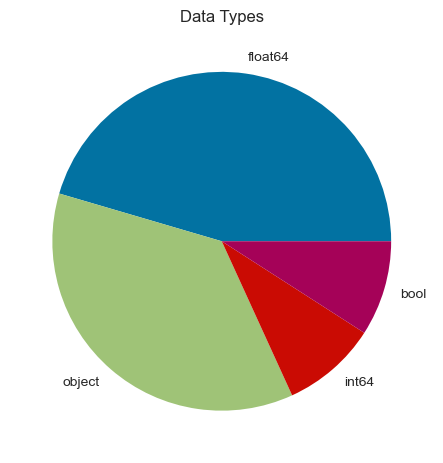

In [22]:
plt.figure()
df.dtypes.value_counts().plot.pie(ylabel='')
plt.title('Data Types')
plt.show()

---

### 6.3 데이터 통계량 확인

실습 데이터에 대해서도 통계량을 확인해봅니다. 숫자 데이터인 int, float에 대해서만 통계량을 확인합니다.

In [23]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Formation Energy (eV),339.0,-2.616950,0.183809,-2.985,-2.7575,-2.605,-2.5255,-2.012
E Above Hull (eV),339.0,0.058215,0.030363,0.000,0.0355,0.062,0.0815,0.190
Band Gap (eV),339.0,2.079740,1.087968,0.000,1.2655,2.499,2.9680,3.823
Nsites,339.0,38.837758,23.133142,10.000,26.0000,31.000,52.0000,132.000
Density (gm/cc),339.0,2.984003,0.353968,2.200,2.7605,2.947,3.1060,4.201
Volume,339.0,467.765619,292.674559,122.581,286.3815,358.537,601.6965,1518.850


---

### 6.4 데이터 고유값 확인


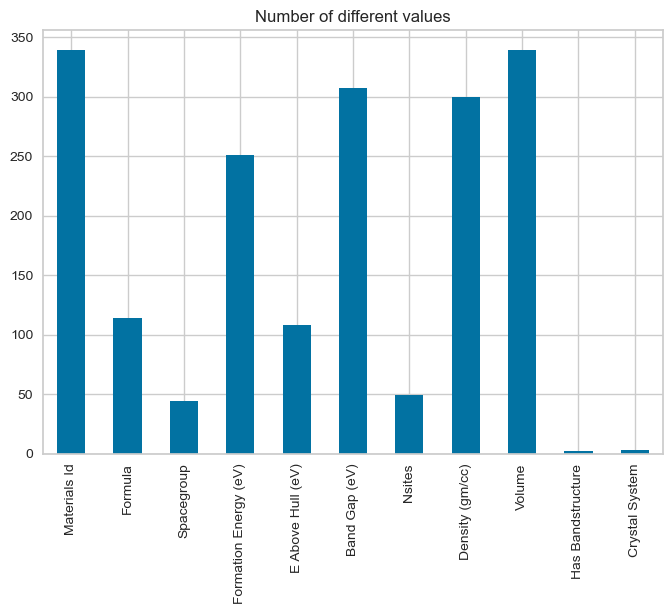

In [24]:
plt.figure()
df.nunique().plot.bar()
plt.title('Number of different values')
plt.show()

Materials ID, Formula, Spacegroup 세 데이터 항목은 글자 데이터이고, 그렇기 때문에 고유값이 많습니다.

Has Bandstructure는 참/거짓으로만 이뤄진 데이터이기 때문에 고유값이 두 개 입니다.

Crystal System은 monoclinic, orthorhombic, triclinic 세 가지 고유값을 가집니다.

---

### 6.5 결측 데이터 전처리

결측 데이터의 갯수와 비율을 확인해봅니다.

In [25]:
isNaN = df.isna().sum().sort_values(ascending=True)
isNaN_ratio = isNaN/df.shape[0]
print("NaN 데이터 갯수: \n", isNaN)
print("\n")
print("NaN 데이터 비율: \n", isNaN_ratio)

NaN 데이터 갯수: 
 Materials Id             0
Formula                  0
Spacegroup               0
Formation Energy (eV)    0
E Above Hull (eV)        0
Band Gap (eV)            0
Nsites                   0
Density (gm/cc)          0
Volume                   0
Has Bandstructure        0
Crystal System           0
dtype: int64


NaN 데이터 비율: 
 Materials Id             0.0
Formula                  0.0
Spacegroup               0.0
Formation Energy (eV)    0.0
E Above Hull (eV)        0.0
Band Gap (eV)            0.0
Nsites                   0.0
Density (gm/cc)          0.0
Volume                   0.0
Has Bandstructure        0.0
Crystal System           0.0
dtype: float64


실습 데이터에는 결측치가 존재하지 않는 것을 확인할 수 있습니다.

따라서, 결측치 대체는 자연스럽게 수행할 필요가 없습니다.

---

### 6.6 이상치 검출 및 제거

토이 데이터셋에 적용했던 방식 그대로, 이상치를 검출하고 제거해봅니다. 동일한 threshold_Z 값을 사용하겠습니다.

In [26]:
df_imputed = df.select_dtypes(include='number')
non_outliers = get_outliers(df_imputed, threshold_Z)

이상치를 총 10개 검출했습니다. 이상치를 갖는 데이터 행은 아래와 같습니다:
Index([33, 44, 45, 113, 211, 231, 265, 266, 270, 277], dtype='int64')


In [27]:
df = df[non_outliers]
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,True,triclinic
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,True,triclinic
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,True,triclinic
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,True,triclinic


총 10 개의 데이터 엔트리가 이상치로 판단되어 제거되었습니다. 따라서, 339 개 데이터에서 329 개 데이터로 감소되었습니다.

---

## 7. 데이터 구분
---
### 7.1 정답 데이터 분리
전처리를 모두 마친 데이터셋에서 정답지로 삼을 데이터 항목을 분리합니다. 본 실습에서는 결정계인 'Crystal System'을 분리합니다.

In [28]:
target_col = 'Crystal System'
y = df[target_col]
display(y)

0      monoclinic
1      monoclinic
2      monoclinic
3      monoclinic
4      monoclinic
          ...    
334     triclinic
335     triclinic
336     triclinic
337     triclinic
338     triclinic
Name: Crystal System, Length: 329, dtype: object

---

### 7.2 클래스 밸런스 확인
정답 데이터를 분류 문제(classification)로 학습하고자 할 때, 정답 데이터를 클래스(class)라고 부릅니다.

이때 클래스 간의 데이터 수가 적절히 비슷해야 학습 성능을 보장할 수 있다.

클래스 간의 불균형(Class Unbalance)이 너무 클 경우, 데이터를 더 획득하거나 기타 머신러닝 기법을 사용해야 한다.


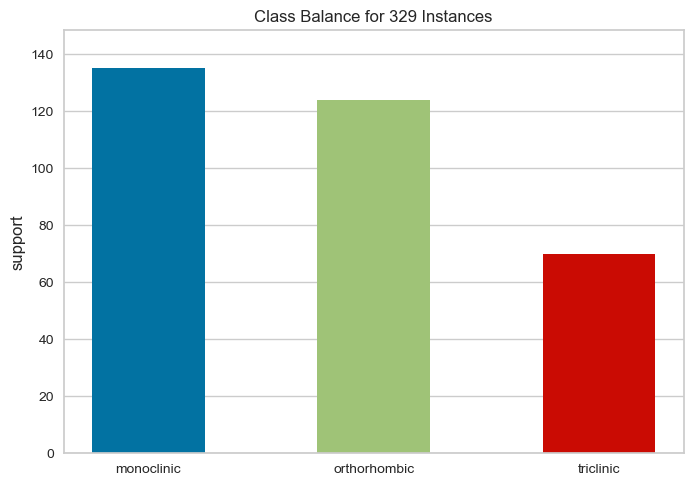

ClassBalance(ax=<Axes: title={'center': 'Class Balance for 329 Instances'}, ylabel='support'>)

In [29]:
from yellowbrick.target import class_balance
class_balance(y)

---

### 7.3 학습, 테스트 데이터셋 구분
학습을 하기 전, 학습에 사용할 데이터와 검증하는데 사용할 데이터를 분리합니다.

실습 데이터의 크기가 작기 때문에, 테스트 데이터를 검증 데이터로 활용하겠습니다.

__학습 데이터를 7, 테스트 데이터를 3__ 의 비율로 구분합니다.

In [30]:
X = df.drop(target_col, axis=1)
display(X)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True
...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,True
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,True
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,True
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,True


random_seed 는 데이터를 구분할 때 랜덤 시드 숫자를 고정하기 위한 변수입니다.

데이터를 랜덤으로 섞은 후 두 데이터셋을 분리하는데, 이때 랜덤하게 데이터를 섞으면 매 실행마다 학습 결과가 달라지게 됩니다.

따라서, 랜덤하게 데이터를 섞되, 시드 숫자를 고정하여 다시 실행했을 때 똑같은 결과를 언제든지 재현할 수 있도록 합니다.

시드 숫자는 어떠한 숫자를 사용해도 괜찮습니다.

In [31]:
from sklearn.model_selection import train_test_split
test_size = 0.3
random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=None,\
                                                           shuffle=True, random_state = random_seed)

In [32]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(230, 10) (230,)
(99, 10) (99,)
